In [1]:
from alc import *
from imports import *
import os
import matplotlib.pyplot as plt
import cupy as cp
import seaborn as sns
from sklearn.metrics import confusion_matrix

from labos.Labo1 import transpuesta
from labos.Labo5 import calculaQR
from labos.Labo8 import svd_reducida


## Lectura de datos

In [2]:
actualPath = os.getcwd()
basePath = os.path.join(actualPath, "cats_and_dogs")
Xt, Yt, Xv, Yv = cargarDataset(basePath)
print("Tamano del dataset training X (Cat, Dog): ", Xt.shape)
print("Tamano del dataset training Y (Cat, Dog): ", Yt.shape)
print("Tamano del dataset verification X (Cat, Dog): ", Xv.shape)
print("Tamano del dataset verification Y (Cat, Dog): ", Yv.shape)

Tamano del dataset training X (Cat, Dog):  (1536, 2000)
Tamano del dataset training Y (Cat, Dog):  (2000, 2)
Tamano del dataset verification X (Cat, Dog):  (1536, 1000)
Tamano del dataset verification Y (Cat, Dog):  (1000, 2)


In [3]:
import random
def random_k_samples(emb, res, k):
    X, Y = [], []
    aux = transpuesta(emb)
    idx = random.sample(range(emb.shape[1]), k) # Garantiza no repetidos
    for r in idx:
        X.append(aux[r])
        Y.append(res[r])
    return transpuesta(np.array(X)), np.array(Y)
        
X,Y = random_k_samples(Xt, Yt,300)
print(X.shape)
print(Y)

(1536, 300)
[[1 0]
 [0 1]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [0 1]
 [1 0]
 [1 0]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [0 1]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [0 1]
 [1 0]
 [1 0]
 [1 0]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [0 1]
 [1 0]
 [1 0]
 [1 0]
 [0 1]
 [0 1]
 [0 1]
 

## Ecuaciones Normales


In [8]:
try:
    W_ep = np.load("W_e_primitivas.npy", allow_pickle=True)
except:
    W_ep = pinvEcuacionesNormales(Xt, transpuesta(Yt))
    print(W_ep.shape)
    r = transpuesta(matmulti(W_ep, Xt))
    print(r.shape)
    np.save("W_e_primitivas.npy", W_ep)

r_eval_ep = transpuesta(matmulti(W_ep, Xv))
print(r_eval_ep)

[[ 0.4107367   1.86426158]
 [ 1.02146957 -0.09785324]
 [ 2.26842642  0.79017503]
 ...
 [-0.02216786  1.56218105]
 [-0.37289576  0.26816936]
 [-0.40202645  0.40937541]]


## Descomposicion en Valores Singulares

In [7]:
try:
    W_svd = np.load("W_svd.npy", allow_pickle=True)
    r_eval_svd = transpuesta(matmulti(W_svd, Xv))
    print(r_eval_svd)
except:
    U, S, VT = svd_reducida(Xt)
    print("U: ", U.shape, " , S:", S.shape," , VT:", VT.shape)
    print("svd ready")
    print("Yt shape:", Yt.shape)
    W_svd  = pinvSVD(U, S, VT.T, Yt)
    np.save("W_svd.npy", W_svd)

[[ 0.41073308  0.57478098]
 [ 1.02146595  0.2973168 ]
 [ 2.26842649 -1.08803723]
 ...
 [-0.02216671  1.08766579]
 [-0.37289066  1.37626334]
 [-0.40202469  0.95050212]]


## Descomposicion QR

In [10]:
try:
    Q = np.load("Q_householder.npy", allow_pickle=True)
    R = np.load("R_householder.npy", allow_pickle=True)
    print("Q: ", Q.shape, ", R: ", R.shape)
except FileNotFoundError:
    Q,R = calculaQR(Xt)
    print("Q: ", Q.shape, ", R: ", R.shape)
    np.save("Q_householder.npy", Q)
    np.save("R_householder.npy", R)


Q:  (2000, 2000) , R:  (2000, 1536)


In [13]:
try:
    W_hh = np.load("W_householder.npy", allow_pickle=True)
    Xp_HH = np.load("Xp_householder.npy", allow_pickle=True)
except:
    W_hh, Xp_HH = pinvHouseHolder(Q,R,transpuesta(Yt))
    np.save("W_householder.npy", W_hh)
    np.save("Xp_householder.npy", Xp_HH)

r_eval_hh = transpuesta(matmulti(W_hh, Xv))
print(r_eval_hh)

[[ 0.41073653  0.57477739]
 [ 1.02146944  0.29731716]
 [ 2.26842636 -1.0880363 ]
 ...
 [-0.02216769  1.0876697 ]
 [-0.37289573  1.37626582]
 [-0.40202675  0.95050597]]


In [ ]:
Q,R = calculaQR(transpuesta(Xt),'GS')
W = pinvGramSchmidt(Q,R,Yt)
np.save("W_gramschmidt.npy", W)
print(W.shape)
r = transpuesta(matmulti(W, X))
print(r)

## Pseudo-Inversa de Moore-Penrose

In [5]:
matrices_a_probar = {
    # "Escalera": W_ep,
    # "SVD": W_svd,
    "Householder": Xp_HH,
}

for nombre, Xp in matrices_a_probar.items():
    print(Xp.shape)
    res =  esPseudoInversa(Xt,transpuesta(Xp))
    print(f"Matriz: {nombre}, Es pseudo-inversa: {res}")



(1536, 2000)
Matriz: Householder, Es pseudo-inversa: True


## Evaluacion y Benchmarking

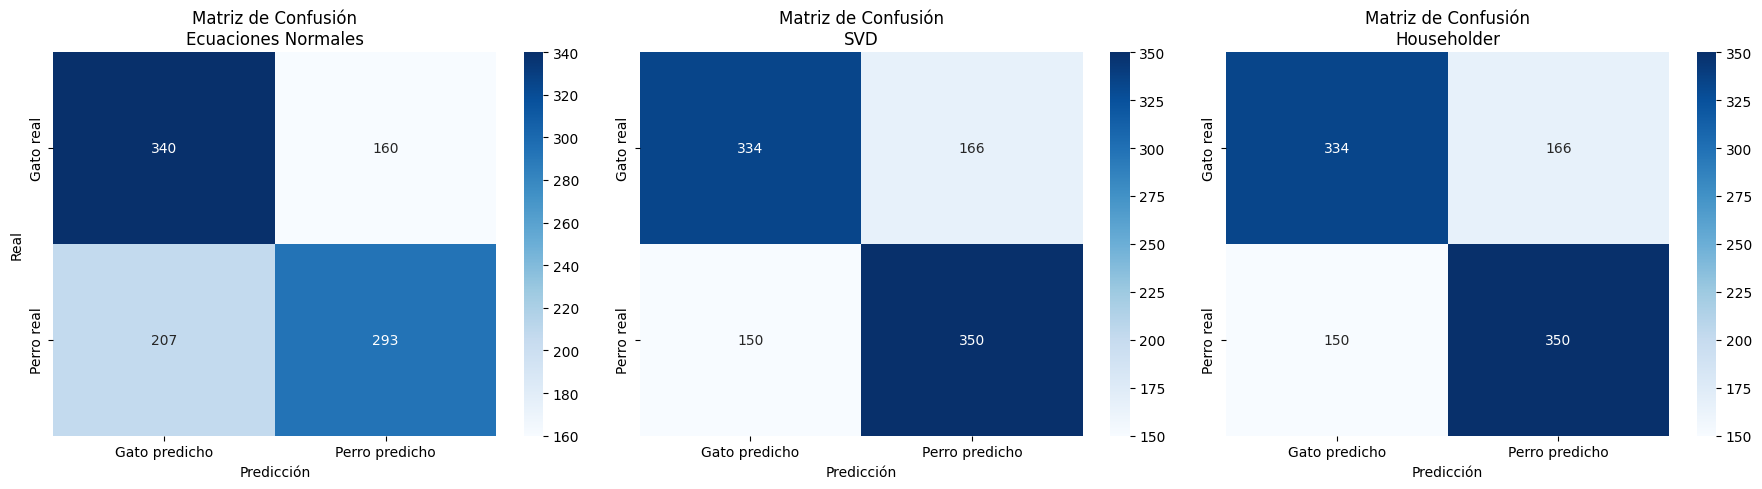

In [12]:
eval_results = {
    "Ecuaciones Normales": r_eval_ep,
    "SVD": r_eval_svd,
    "Householder": r_eval_hh,
}

fig, axes = plt.subplots(1, len(eval_results), figsize=(18, 5))

for i, (method_name, r_eval) in enumerate(eval_results.items()):
    matriz_c = confusion_matrix(np.argmax(Yv, axis=1), np.argmax(r_eval, axis=1))
    
    sns.heatmap(matriz_c, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Gato predicho', 'Perro predicho'],
                yticklabels=['Gato real', 'Perro real'],
                ax=axes[i]) 
    
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Real' if i == 0 else '') 
    axes[i].set_title(f'Matriz de Confusión\n{method_name}')

plt.tight_layout()